In [35]:
print('Hello World')

Hello World


## Business Problem : 

A telecom company is losing customers every month.


The company wants to:

- Predict which customers are likely to leave
- Reduce revenue loss
- Improve customer retention
- Take preventive action before customers churn

## Business Objective : 

1. To reduce Churn rate.

2. Increase Profit

3. Indentify Risky Customers Early 

4. Improve Customer Satisfaction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

import joblib
from IPython.display import display

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv.xls")

In [38]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [39]:
df.shape

(7043, 21)

In [40]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Churn
No     5174
Yes    1869
Name: count, dtype: int64


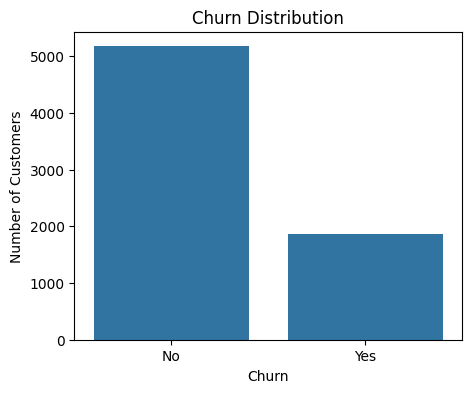

In [42]:
print(df["Churn"].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [43]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print("Churn percentage:")
print(churn_rate)

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [3]:
clean_df = df.copy()

clean_df = clean_df.drop("customerID", axis=1)
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")

print("Missing TotalCharges values:", clean_df["TotalCharges"].isnull().sum())

clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(clean_df["TotalCharges"].median())


Missing TotalCharges values: 11


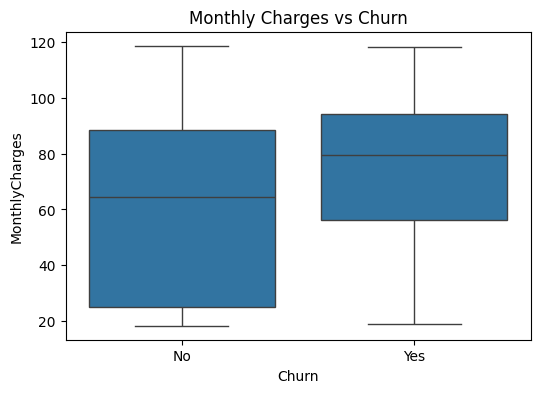

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=clean_df)
plt.title("Monthly Charges vs Churn")
plt.show()

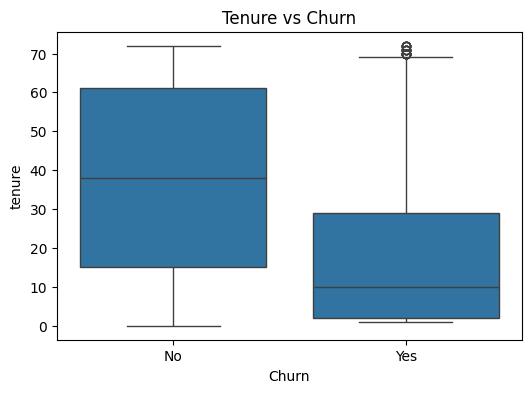

In [46]:
plt.figure(figsize=(6,4))
s.boxplot if False else sns.boxplot(x="Churn", y="tenure", data=clean_df)
plt.title("Tenure vs Churn")
plt.show()

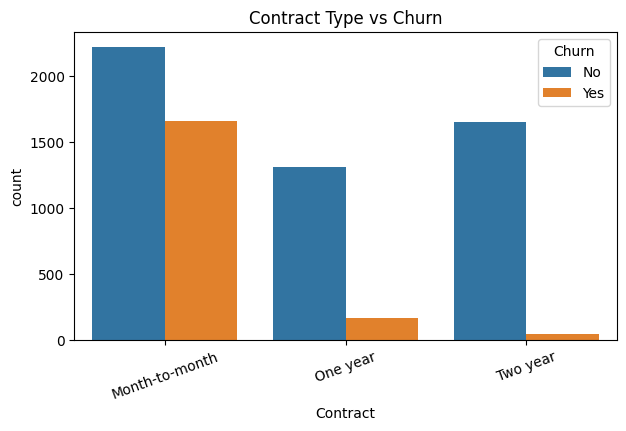

In [47]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=clean_df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

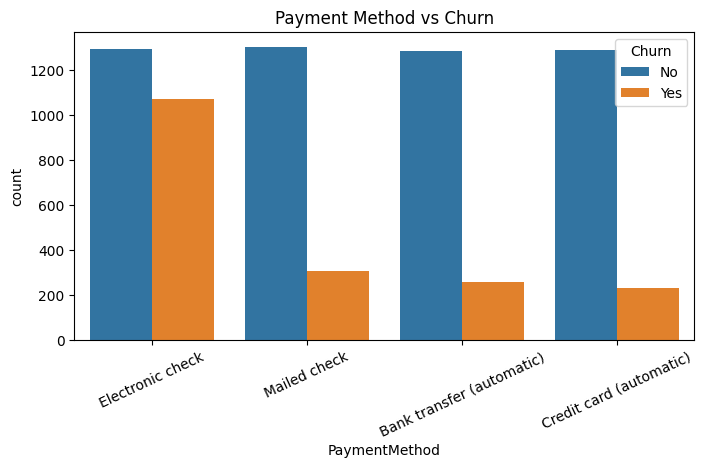

In [48]:
plt.figure(figsize=(8,4))
sns.countplot(x="PaymentMethod", hue="Churn", data=clean_df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=25)
plt.show()

In [4]:
label_encoder = LabelEncoder()

for column in clean_df.columns:
    if pd.api.types.is_string_dtype(clean_df[column]) or pd.api.types.is_object_dtype(clean_df[column]):
        clean_df[column] = label_encoder.fit_transform(clean_df[column])

clean_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [5]:
X = clean_df.drop("Churn", axis=1)
y = clean_df["Churn"]

In [51]:
print("Feature columns:")
print(X.columns)

print("Target column:")
print("Churn")

Feature columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')
Target column:
Churn


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (5634, 19)
Testing data size: (1409, 19)


In [7]:
model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)

model.fit(X_train, y_train)

/Users/santhoshkumarv/Library/Python/3.11/lib/python/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [8]:
# Getting  churn probability for each customer

churn_probability = model.predict_proba(X_test)[:, 1]

best_threshold = 0.50
best_recall = 0
best_accuracy = 0

for threshold in np.arange(0.20, 0.81, 0.01):
    temp_prediction = (churn_probability >= threshold).astype(int)
    temp_accuracy = accuracy_score(y_test, temp_prediction)
    temp_recall = recall_score(y_test, temp_prediction)

    if temp_accuracy >= 0.75 and temp_recall > best_recall:
        best_threshold = threshold
        best_recall = temp_recall
        best_accuracy = temp_accuracy

y_pred = (churn_probability >= best_threshold).astype(int)

print("Best threshold:", round(best_threshold, 2))
print("Accuracy at best threshold:", round(best_accuracy, 3))
print("Recall at best threshold:", round(best_recall, 3))


Best threshold: 0.55
Accuracy at best threshold: 0.75
Recall at best threshold: 0.757


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Optimized Threshold:")
print(round(best_threshold, 2))

print("Accuracy Score:")
print(accuracy)

print("Recall Score:")
print(recall_score(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Optimized Threshold:
0.55
Accuracy Score:
0.7501774308019872
Recall Score:
0.7566844919786097
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



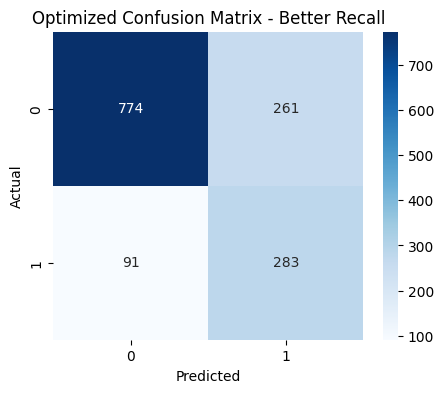

[[774 261]
 [ 91 283]]


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Optimized Confusion Matrix - Better Recall")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(cm)

In [11]:
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0 1 0 1 0 1 1 0 0 1]


In [12]:
comparison = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred[:10]
})

print(comparison)

      Actual  Predicted
437        0          0
2280       0          1
2235       0          0
4460       0          1
3761       0          0
5748       0          1
3568       0          1
2976       0          0
5928       0          0
1639       1          1


In [58]:
importance = pd.DataFrame({ "Feature": X.columns,"Coefficient": model.coef_[0]})

importance = importance.sort_values(by="Coefficient", ascending=False)

print("Feature Importance:")
display(importance)

Feature Importance:


,Feature,Coefficient
15,PaperlessBilling,0.358256
7,InternetService,0.227135
1,SeniorCitizen,0.181249
6,MultipleLines,0.072275
2,Partner,0.068324
16,PaymentMethod,0.058145
13,StreamingMovies,0.035035
17,MonthlyCharges,0.021966
18,TotalCharges,0.000283
12,StreamingTV,-0.014028


In [59]:
sample_customer = X_test.iloc[0:1]

probability = model.predict_proba(sample_customer)
prediction = 1 if probability[0][1] >= best_threshold else 0

print("Sample Prediction:")

if prediction == 1:
    print("Customer is likely to churn")
else:
    print("Customer is NOT likely to churn")

print("Churn probability:")
print(probability[0][1])

print("Threshold used:")
print(round(best_threshold, 2))

Sample Prediction:
Customer is likely to churn
Churn probability:
0.6523980018936969
Threshold used:
0.26


In [60]:
risk_customers = X_test.copy()
risk_customers["Actual_Churn"] = y_test
risk_customers["Churn_Probability"] = churn_probability

risk_customers = risk_customers.sort_values(by="Churn_Probability", ascending=False)

print("Top 10 risky customers:")
display(risk_customers.head(10))

Top 10 risky customers:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability
2208,0,1,1,0,1,1,2,1,0,0,...,0,2,2,0,1,2,100.80,100.80,1,0.839816
1410,0,1,0,0,2,1,2,1,0,0,...,0,2,2,0,1,2,93.85,170.85,1,0.827163
4800,1,1,0,0,1,1,2,1,0,0,...,0,2,2,0,1,2,94.00,94.00,1,0.825081
2577,0,0,0,0,1,1,2,1,0,0,...,0,2,2,0,1,2,94.60,94.60,1,0.807622
2191,0,1,0,0,1,1,0,1,0,0,...,0,2,2,0,1,2,91.30,91.30,1,0.801852
3346,0,1,0,0,2,1,2,1,0,0,...,0,0,2,0,1,2,84.05,186.05,0,0.799431
585,0,1,0,0,1,1,2,1,0,0,...,0,2,0,0,1,2,85.70,85.70,1,0.793769
3078,0,1,0,0,2,1,2,1,0,0,...,0,2,0,0,1,2,85.55,187.45,1,0.788842
3352,0,0,0,0,1,1,2,1,0,0,...,0,0,2,0,1,3,85.45,85.45,1,0.788725
2184,0,1,0,0,2,1,2,1,0,0,...,0,0,2,0,1,2,88.55,179.25,1,0.788245


## Based on the analysis:

1. Customers with high monthly charges are more likely to churn.
2. Customers with short tenure are more likely to leave.
3. Month-to-month contract customers have higher churn.
4. Electronic check payment customers show higher churn.
5. Long-term contract customers are more stable.

## Business Recommendations

1. Give special offers to high-risk customers.
2. Encourage month-to-month customers to move to yearly contracts.
3. Contact new customers early and improve onboarding.
4. Provide discounts or support to customers with high monthly charges.